In [16]:
import subprocess, sys

packages = [
    'mlxtend',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'openpyxl',
    'imbalanced-learn',
    'wordcloud',
    'scipy'
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed')

All packages installed


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
import sys
np.random.seed(42)
from scipy import stats as scipy_stats

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)
from imblearn.over_sampling import SMOTE

In [18]:
FILE_PATH = 'online_retail.csv'

df = pd.read_csv(FILE_PATH, dtype={'CustomerID': str}, encoding='latin1')

print(f'Loaded: {len(df):,} rows, {df.shape[1]} columns')
df.head()

Loaded: 1,067,371 rows, 8 columns


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [19]:
print(f'Rows before cleaning: {len(df):,}')

df.columns = df.columns.str.strip()
if 'Customer ID' in df.columns:
    df = df.rename(columns={'Customer ID': 'CustomerID'})
if 'Invoice' in df.columns:
    df = df.rename(columns={'Invoice': 'InvoiceNo'})
if 'Price' in df.columns and 'UnitPrice' not in df.columns:
    df = df.rename(columns={'Price': 'UnitPrice'})

df = df.dropna(subset=['CustomerID', 'Description'])
print(f'After removing missing values  : {len(df):,}')

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'After removing cancellations   : {len(df):,}')

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f'After removing bad qty/price   : {len(df):,}')

df = df[df['Country'] == 'United Kingdom']
print(f'After keeping UK only          : {len(df):,}')

df['Description'] = df['Description'].str.strip().str.upper()

print(f'\nUnique invoices  : {df["InvoiceNo"].nunique():,}')
print(f'Unique products  : {df["Description"].nunique():,}')
print('Saved')

Rows before cleaning: 1,067,371
After removing missing values  : 824,364
After removing cancellations   : 805,620
After removing bad qty/price   : 805,549
After keeping UK only          : 725,250

Unique invoices  : 33,541
Unique products  : 5,206
Saved


In [20]:
TOP_N = 150

top_products = (
    df.groupby('Description')['InvoiceNo']
    .nunique()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index.tolist()
)

df_top = df[df['Description'].isin(top_products)]

basket = (
    df_top
    .groupby(['InvoiceNo', 'Description'])['Quantity']
    .sum()
    .unstack(fill_value=0)
    .reset_index(drop=True)
)

basket = basket.map(lambda x: 1 if x > 0 else 0)
assert basket.shape[0] > 0, "Basket is empty!"
assert basket.shape[1] > 0, "No products found!"
print(f'Basket: {basket.shape[0]:,} transactions x {basket.shape[1]} products')
print(f'Matrix density: {basket.values.mean()*100:.2f}%')
basket.iloc[:5, :6]

Basket: 27,738 transactions x 150 products
Matrix density: 3.89%


Description,3 STRIPEY MICE FELTCRAFT,6 RIBBONS RUSTIC CHARM,60 CAKE CASES VINTAGE CHRISTMAS,60 TEATIME FAIRY CAKE CASES,72 SWEETHEART FAIRY CAKE CASES,ALARM CLOCK BAKELIKE GREEN
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


Item Frequency Analysis
Total transactions       : 27,738
Most popular product     : WHITE HANGING HEART T-LIGHT HOLDER — 4,701 transactions
Least popular product    : JUMBO BAG WOODLAND ANIMALS — 706 transactions
Median frequency         : 919 transactions
Imbalance ratio          : 6.7x
Minority items (rare)    : 75 (50%)
Majority items (popular) : 75 (50%)
Gini coefficient         : 0.1960 (closer to 1 = more imbalanced)


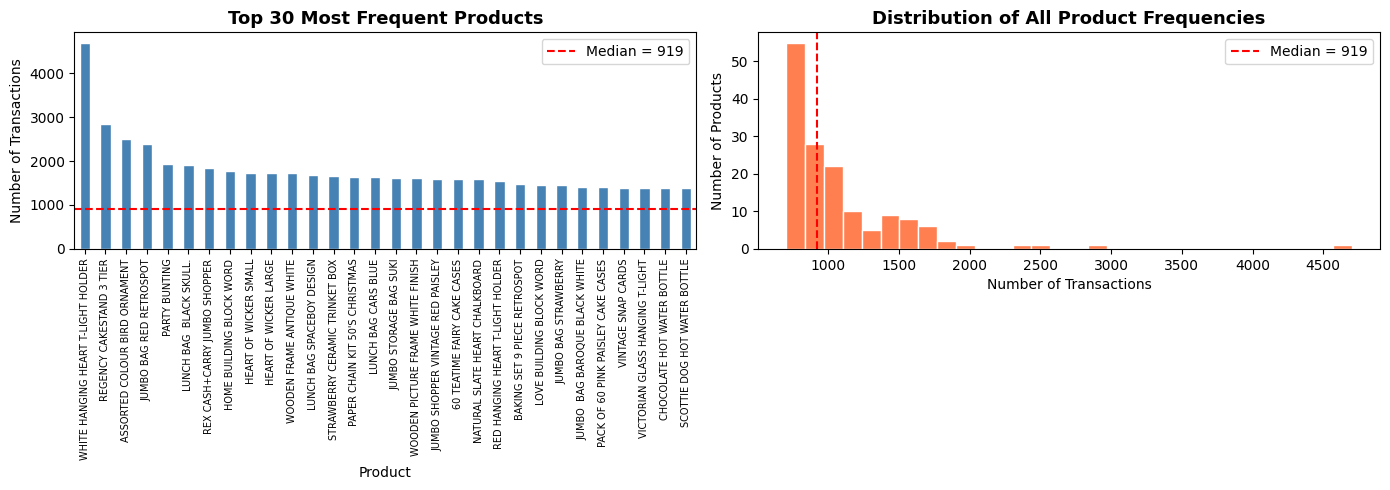

Saved: outputs/fig1_imbalance.png


In [21]:
item_freq = basket.sum().sort_values(ascending=False)
total_transactions = len(basket)
median_freq = item_freq.median()

minority_items = set(item_freq[item_freq < median_freq].index)
majority_items = set(item_freq[item_freq >= median_freq].index)

print('Item Frequency Analysis')
print(f'Total transactions       : {total_transactions:,}')
print(f'Most popular product     : {item_freq.idxmax()} — {item_freq.max():,} transactions')
print(f'Least popular product    : {item_freq.idxmin()} — {item_freq.min():,} transactions')
print(f'Median frequency         : {median_freq:.0f} transactions')
print(f'Imbalance ratio          : {item_freq.max()/item_freq.min():.1f}x')
print(f'Minority items (rare)    : {len(minority_items)} ({len(minority_items)/len(item_freq)*100:.0f}%)')
print(f'Majority items (popular) : {len(majority_items)} ({len(majority_items)/len(item_freq)*100:.0f}%)')

def gini(array):
    array = np.sort(np.array(array, dtype=float))
    n = len(array)
    index = np.arange(1, n+1)
    return (2 * np.sum(index * array) / (n * np.sum(array))) - (n+1)/n

g = gini(item_freq.values)
print(f'Gini coefficient         : {g:.4f} (closer to 1 = more imbalanced)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

item_freq.head(30).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axhline(median_freq, color='red', linestyle='--', label=f'Median = {median_freq:.0f}')
axes[0].set_title('Top 30 Most Frequent Products', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].legend()

axes[1].hist(item_freq.values, bins=30, color='coral', edgecolor='white')
axes[1].axvline(median_freq, color='red', linestyle='--', label=f'Median = {median_freq:.0f}')
axes[1].set_title('Distribution of All Product Frequencies', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Number of Transactions')
axes[1].set_ylabel('Number of Products')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/fig1_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig1_imbalance.png')

In [22]:
MIN_SUPPORT    = 0.01
MIN_CONFIDENCE = 0.3
MIN_LIFT       = 1.0
MAX_LEN        = 3

basket_bool = basket.astype(bool)

print('Running Apriori')
t_start = time.time()
freq_ap_orig = apriori(basket_bool, min_support=MIN_SUPPORT,
                       use_colnames=True, max_len=MAX_LEN)
rules_ap_orig = association_rules(freq_ap_orig, metric='confidence',
                                  min_threshold=MIN_CONFIDENCE)
rules_ap_orig = rules_ap_orig[rules_ap_orig['lift'] >= MIN_LIFT].copy()
time_ap_orig = round(time.time() - t_start, 3)
print(f'  Rules found : {len(rules_ap_orig)}')
print(f'  Time taken  : {time_ap_orig} seconds')

print('Running FP-Growth')
t_start = time.time()
freq_fp_orig = fpgrowth(basket_bool, min_support=MIN_SUPPORT,
                        use_colnames=True, max_len=MAX_LEN)
rules_fp_orig = association_rules(freq_fp_orig, metric='confidence',
                                  min_threshold=MIN_CONFIDENCE)
rules_fp_orig = rules_fp_orig[rules_fp_orig['lift'] >= MIN_LIFT].copy()
time_fp_orig = round(time.time() - t_start, 3)
print(f'  Rules found : {len(rules_fp_orig)}')
print(f'  Time taken  : {time_fp_orig} seconds')

print(f'FP-Growth was {time_ap_orig/max(time_fp_orig,0.001):.1f}x faster than Apriori')

Running Apriori
  Rules found : 329
  Time taken  : 1.07 seconds
Running FP-Growth
  Rules found : 329
  Time taken  : 0.729 seconds
FP-Growth was 1.5x faster than Apriori


In [23]:
print('Rule Quality')

for name, rules in [('Apriori', rules_ap_orig), ('FP-Growth', rules_fp_orig)]:
    print(f'{name}:')
    print(f'  Total rules      : {len(rules)}')
    print(f'  Avg support      : {rules["support"].mean():.4f}')
    print(f'  Avg confidence   : {rules["confidence"].mean():.4f}')
    print(f'  Avg lift         : {rules["lift"].mean():.4f}')
    print(f'  Max lift         : {rules["lift"].max():.4f}')
    print(f'  Avg conviction   : {rules["conviction"].mean():.4f}')
    print(f'  Execution time   : {time_ap_orig if name=="Apriori" else time_fp_orig} seconds')

Rule Quality
Apriori:
  Total rules      : 329
  Avg support      : 0.0149
  Avg confidence   : 0.4478
  Avg lift         : 9.6863
  Max lift         : 25.5497
  Avg conviction   : 1.8098
  Execution time   : 1.07 seconds
FP-Growth:
  Total rules      : 329
  Avg support      : 0.0149
  Avg confidence   : 0.4478
  Avg lift         : 9.6863
  Max lift         : 25.5497
  Avg conviction   : 1.8098
  Execution time   : 0.729 seconds


In [24]:
def count_minority_rules(rules, minority_items):
    count = 0
    for _, row in rules.iterrows():
        all_items = set(row['antecedents']) | set(row['consequents'])
        if all_items & minority_items:
            count += 1
    return count
def weighted_minority_score(rules, minority_items):
    score = 0
    for _, row in rules.iterrows():
        items = set(row['antecedents']) | set(row['consequents'])
        if items & minority_items:
            score += row['lift']
    return round(score / max(len(rules),1), 4)

def rule_stats(rules, minority_items, exec_time=None):
    """Returns a full dictionary of rule quality stats."""
    minority_count = count_minority_rules(rules, minority_items)
    return {
        'n_rules'        : len(rules),
        'avg_support'    : round(rules['support'].mean(), 4)     if len(rules) else 0,
        'avg_confidence' : round(rules['confidence'].mean(), 4)  if len(rules) else 0,
        'avg_lift'       : round(rules['lift'].mean(), 4)        if len(rules) else 0,
        'max_lift'       : round(rules['lift'].max(), 4)         if len(rules) else 0,
        'avg_conviction' : round(rules['conviction'].mean(), 4)  if len(rules) else 0,
        'minority_rules' : minority_count,
        'weighted_minority_score': weighted_minority_score(rules, minority_items),
        'minority_pct'   : round(minority_count / max(len(rules),1) * 100, 1),
        'exec_time_s'    : exec_time,
        'rules'          : rules
    }

ap_orig_stats = rule_stats(rules_ap_orig, minority_items, time_ap_orig)
fp_orig_stats = rule_stats(rules_fp_orig, minority_items, time_fp_orig)

print('Minority Item Coverage')
print(f'Apriori  : {ap_orig_stats["minority_rules"]} / {ap_orig_stats["n_rules"]} rules '
      f'({ap_orig_stats["minority_pct"]}%) involve rare items')
print(f'FP-Growth: {fp_orig_stats["minority_rules"]} / {fp_orig_stats["n_rules"]} rules '
      f'({fp_orig_stats["minority_pct"]}%) involve rare items')

Minority Item Coverage
Apriori  : 119 / 329 rules (36.2%) involve rare items
FP-Growth: 119 / 329 rules (36.2%) involve rare items


In [25]:
def show_top_rules(rules, label, n=10):
    top = rules.sort_values('lift', ascending=False).head(n).copy()
    top['antecedents'] = top['antecedents'].apply(lambda x: ', '.join(list(x)))
    top['consequents'] = top['consequents'].apply(lambda x: ', '.join(list(x)))
    print(f'TOP {n} rules — {label}')
    display(top[['antecedents','consequents','support','confidence','lift','conviction']]
            .reset_index(drop=True))

show_top_rules(rules_ap_orig,  'Apriori — Original Data')
show_top_rules(rules_fp_orig, 'FP-Growth — Original Data')

TOP 10 rules — Apriori — Original Data


,antecedents,consequents,support,confidence,lift,conviction
0,"ROSES REGENCY TEACUP AND SAUCER, REGENCY CAKES...",GREEN REGENCY TEACUP AND SAUCER,0.013555,0.762677,25.549696,4.087894
1,GREEN REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER, REGENCY CAKES...",0.013555,0.454106,25.549696,1.799300
2,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...",ROSES REGENCY TEACUP AND SAUCER,0.013555,0.837416,25.248107,5.946682
3,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...",0.013555,0.408696,25.248107,1.663801
4,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.023722,0.715217,23.959783,3.406631
5,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.023722,0.794686,23.959783,4.709043
6,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.017773,0.620126,22.692677,2.560513
7,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.017773,0.650396,22.692677,2.778396
8,BATHROOM METAL SIGN,TOILET METAL SIGN,0.019900,0.534366,20.964982,2.092870
9,TOILET METAL SIGN,BATHROOM METAL SIGN,0.019900,0.780764,20.964982,4.391422


TOP 10 rules — FP-Growth — Original Data


,antecedents,consequents,support,confidence,lift,conviction
0,"ROSES REGENCY TEACUP AND SAUCER, REGENCY CAKES...",GREEN REGENCY TEACUP AND SAUCER,0.013555,0.762677,25.549696,4.087894
1,GREEN REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER, REGENCY CAKES...",0.013555,0.454106,25.549696,1.799300
2,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...",0.013555,0.408696,25.248107,1.663801
3,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...",ROSES REGENCY TEACUP AND SAUCER,0.013555,0.837416,25.248107,5.946682
4,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.023722,0.715217,23.959783,3.406631
5,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.023722,0.794686,23.959783,4.709043
6,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.017773,0.650396,22.692677,2.778396
7,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.017773,0.620126,22.692677,2.560513
8,BATHROOM METAL SIGN,TOILET METAL SIGN,0.019900,0.534366,20.964982,2.092870
9,TOILET METAL SIGN,BATHROOM METAL SIGN,0.019900,0.780764,20.964982,4.391422


In [26]:
np.random.seed(42)

minority_cols = [c for c in basket.columns if c in minority_items]
majority_cols = [c for c in basket.columns if c in majority_items]

# METHOD 1: RANDOM OVERSAMPLING
minority_mask = basket[minority_cols].sum(axis=1) > 0
minority_transactions = basket[minority_mask]
OVERSAMPLE_TIMES = 3
extra = pd.concat([minority_transactions] * OVERSAMPLE_TIMES, ignore_index=True)
basket_over = pd.concat([basket, extra], ignore_index=True)

print('METHOD 1: Random Oversampling')
print(f'  Original     : {len(basket):,} transactions')
print(f'  Oversampled  : {len(basket_over):,} transactions')

# METHOD 2: RANDOM UNDERSAMPLING
popularity_cutoff = item_freq.quantile(0.85)
dominant_items = [c for c in item_freq[item_freq > popularity_cutoff].index
                  if c in basket.columns]

basket_under = basket.copy()
for item in dominant_items:
    rows_with_item = basket_under[basket_under[item] == 1].index.tolist()
    n_remove = int(len(rows_with_item) * 0.40)
    if n_remove > 0:
        to_remove = np.random.choice(rows_with_item, size=n_remove, replace=False)
        basket_under = basket_under.drop(index=to_remove)
basket_under = basket_under.reset_index(drop=True)

print('METHOD 2: Random Undersampling')
print(f'  Original     : {len(basket):,} transactions')
print(f'  Undersampled : {len(basket_under):,} transactions')

# METHOD 3: HYBRID
basket_hybrid = basket_over.copy()
for item in dominant_items:
    rows_with_item = basket_hybrid[basket_hybrid[item] == 1].index.tolist()
    n_remove = int(len(rows_with_item) * 0.20)
    if n_remove > 0:
        to_remove = np.random.choice(rows_with_item, size=n_remove, replace=False)
        basket_hybrid = basket_hybrid.drop(index=to_remove)
basket_hybrid = basket_hybrid.reset_index(drop=True)

print('METHOD 3: Hybrid Balancing')
print(f'  Original : {len(basket):,} transactions')
print(f'  Hybrid   : {len(basket_hybrid):,} transactions')

METHOD 1: Random Oversampling
  Original     : 27,738 transactions
  Oversampled  : 91,053 transactions
METHOD 2: Random Undersampling
  Original     : 27,738 transactions
  Undersampled : 15,912 transactions
METHOD 3: Hybrid Balancing
  Original : 27,738 transactions
  Hybrid   : 66,872 transactions


In [27]:
#METHOD 4: SMOTE
print('METHOD 4: SMOTE')

minority_cols = [c for c in basket.columns if c in minority_items]
y = (basket[minority_cols].sum(axis=1) > 0).astype(int)

print(f'  Minority transactions (y=1): {y.sum():,}')
print(f'  Majority transactions (y=0): {(y==0).sum():,}')

smote = SMOTE(random_state=42, k_neighbors=3)
basket_smote_values, y_smote = smote.fit_resample(basket, y)

basket_smote = pd.DataFrame(basket_smote_values, columns=basket.columns)
basket_smote = basket_smote.clip(0, 1).round().astype(int)

print(f'  Original : {len(basket):,} transactions')
print(f'  SMOTE    : {len(basket_smote):,} transactions')
print(f'  Minority after balancing: {(basket_smote[minority_cols].sum(axis=1) > 0).sum():,}')

METHOD 4: SMOTE
  Minority transactions (y=1): 21,105
  Majority transactions (y=0): 6,633
  Original : 27,738 transactions
  SMOTE    : 42,210 transactions
  Minority after balancing: 21,105


Gini Coefficients:
  Original       : 0.196
  Oversampled    : 0.1635
  Undersampled   : 0.1578
  Hybrid         : 0.1314
  SMOTE          : 0.2589


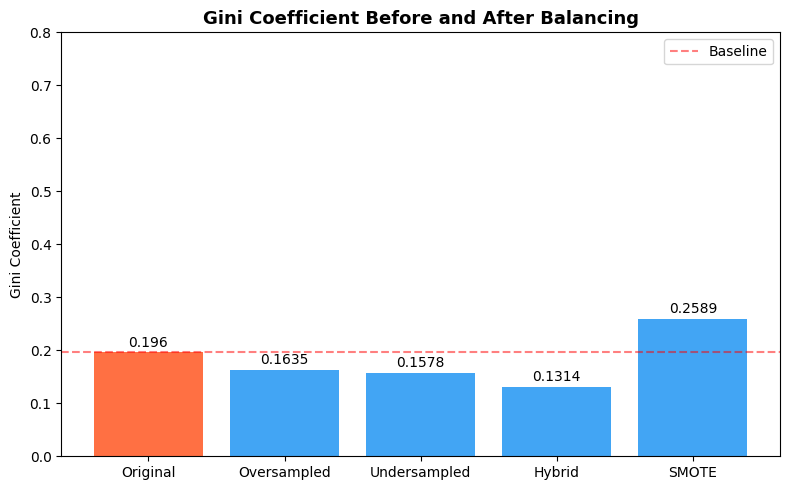

Saved


In [28]:
datasets = {
    'Original': basket,
    'Oversampled': basket_over,
    'Undersampled': basket_under,
    'Hybrid': basket_hybrid,
    'SMOTE': basket_smote
}

gini_scores = {}
for name, bsk in datasets.items():
    freq = bsk.sum()
    gini_scores[name] = round(gini(freq.values), 4)

print('Gini Coefficients:')
for name, score in gini_scores.items():
    print(f'  {name:<15}: {score}')

plt.figure(figsize=(8, 5))
colors = ['#FF5722' if k == 'Original' else '#2196F3' for k in gini_scores.keys()]
bars = plt.bar(gini_scores.keys(), gini_scores.values(), color=colors, alpha=0.85)

for bar, val in zip(bars, gini_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             str(val), ha='center', va='bottom', fontsize=10)

plt.title('Gini Coefficient Before and After Balancing', fontweight='bold', fontsize=13)
plt.ylabel('Gini Coefficient')
plt.ylim(0, 0.8)
plt.axhline(y=gini_scores['Original'], color='red', linestyle='--', alpha=0.5, label='Baseline')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/fig6_gini_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved')

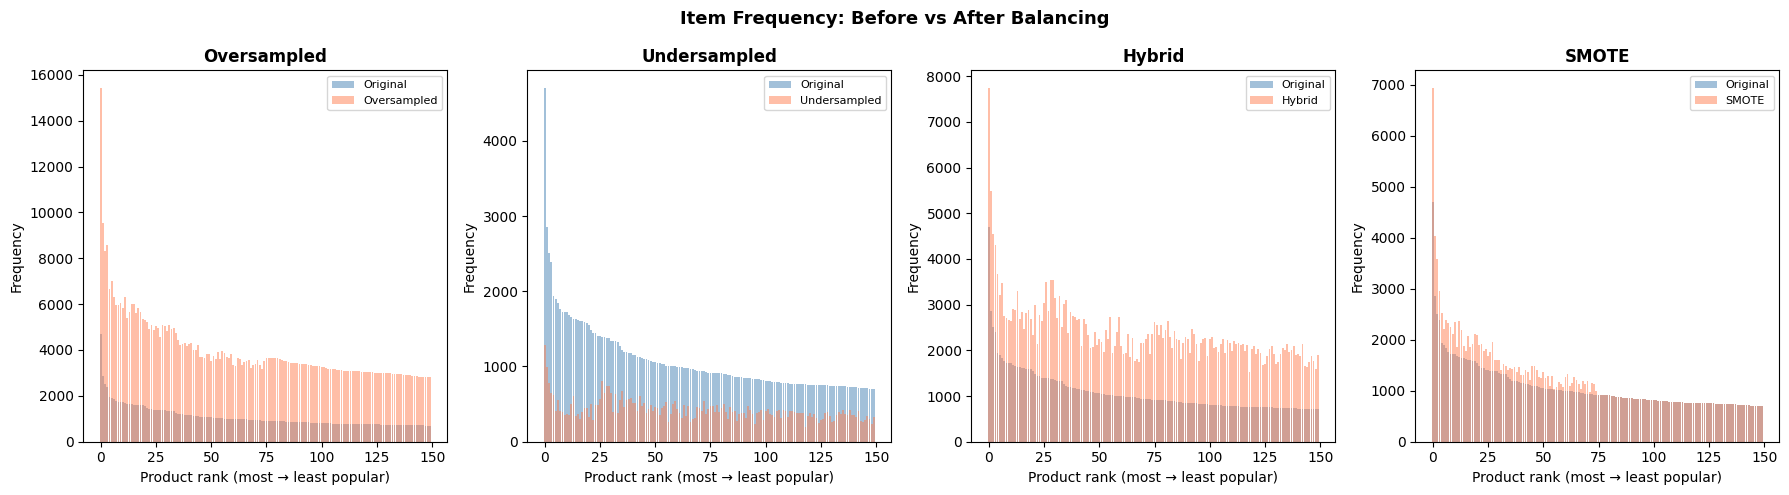

Saved: outputs/fig2_balance_comparison.png


In [29]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (label, bsk) in zip(axes, [
    ('Oversampled',  basket_over),
    ('Undersampled', basket_under),
    ('Hybrid',       basket_hybrid),
    ('SMOTE',        basket_smote)
]):
    before = basket.sum().sort_values(ascending=False)
    after  = bsk.sum().reindex(before.index)

    ax.bar(range(len(before)), before.values, alpha=0.5, label='Original', color='steelblue')
    ax.bar(range(len(after)),  after.values,  alpha=0.5, label=label,      color='coral')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Product rank (most → least popular)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Item Frequency: Before vs After Balancing', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/fig2_balance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig2_balance_comparison.png')

In [30]:
def run_algorithm(basket_df, algo_fn):
    """Run a single algorithm and return rules and execution time."""
    b = basket_df.astype(bool)
    t0 = time.time()
    
    freq = algo_fn(b, min_support=MIN_SUPPORT,
                   use_colnames=True, max_len=MAX_LEN)
    
    rules = association_rules(freq, metric='confidence',
                              min_threshold=MIN_CONFIDENCE)
    
    rules = rules[rules['lift'] >= MIN_LIFT].copy()
    
    elapsed = round(time.time() - t0, 3)
    
    return rules, elapsed

In [31]:
def run_experiment(basket_df, label):
    """Run Apriori and FP-Growth on a basket. Return rules and full stats."""
    b = basket_df.astype(bool)
    output = {}

    for algo_name, algo_fn in [('Apriori', apriori), ('FP-Growth', fpgrowth)]:
        print(f'  [{label}] {algo_name}...', end=' ', flush=True)

        rules, elapsed = run_algorithm(basket_df, algo_fn)

        stats = rule_stats(rules, minority_items, elapsed)
        output[algo_name] = stats

        print(f'{stats["n_rules"]} rules | '
              f'minority: {stats["minority_pct"]}% | '
              f'time: {elapsed}s')

    return output


print('Running experiments...')

all_results = {
    'Original': run_experiment(basket,       'Original'),
    'Oversampled': run_experiment(basket_over,  'Oversampled'),
    'Undersampled': run_experiment(basket_under, 'Undersampled'),
    'Hybrid': run_experiment(basket_hybrid, 'Hybrid'),
}

print('Done')
for ds, res in all_results.items():
    for algo, stats in res.items():
        assert stats['n_rules'] >= 0, f"Error in {ds}-{algo}"

Running experiments...
  [Original] Apriori... 329 rules | minority: 36.2% | time: 1.142s
  [Original] FP-Growth... 329 rules | minority: 36.2% | time: 0.825s
  [Oversampled] Apriori... 469 rules | minority: 39.9% | time: 5.675s
  [Oversampled] FP-Growth... 469 rules | minority: 39.9% | time: 1.303s
  [Undersampled] Apriori... 67 rules | minority: 52.2% | time: 0.381s
  [Undersampled] FP-Growth... 67 rules | minority: 52.2% | time: 0.185s
  [Hybrid] Apriori... 204 rules | minority: 49.5% | time: 2.186s
  [Hybrid] FP-Growth... 204 rules | minority: 49.5% | time: 0.922s
Done


In [32]:
all_results['SMOTE'] = run_experiment(basket_smote, 'SMOTE')

rows = []
for dataset_name, algo_results in all_results.items():
    for algo_name, s in algo_results.items():
        rows.append({
            'Dataset'        : dataset_name,
            'Algorithm'      : algo_name,
            'Total Rules'    : s['n_rules'],
            'Avg Support'    : s['avg_support'],
            'Avg Confidence' : s['avg_confidence'],
            'Avg Lift'       : s['avg_lift'],
            'Max Lift'       : s['max_lift'],
            'Avg Conviction' : s['avg_conviction'],
            'Minority Rules' : s['minority_rules'],
            'Minority %'     : s['minority_pct'],
            'Exec Time (s)'  : s['exec_time_s'],
        })

summary = pd.DataFrame(rows)

print('Result Summary')
print(summary.to_string(index=False))

summary.to_csv('outputs/results_table.csv', index=False)
summary.to_excel('outputs/results_summary.xlsx', index=False)
print('Saved')

  [SMOTE] Apriori... 137 rules | minority: 14.6% | time: 1.074s
  [SMOTE] FP-Growth... 137 rules | minority: 14.6% | time: 0.882s
Result Summary
     Dataset Algorithm  Total Rules  Avg Support  Avg Confidence  Avg Lift  Max Lift  Avg Conviction  Minority Rules  Minority %  Exec Time (s)
    Original   Apriori          329       0.0149          0.4478    9.6863   25.5497          1.8098             119        36.2          1.142
    Original FP-Growth          329       0.0149          0.4478    9.6863   25.5497          1.8098             119        36.2          0.825
 Oversampled   Apriori          469       0.0155          0.4502    8.5999   21.7964          1.8245             187        39.9          5.675
 Oversampled FP-Growth          469       0.0155          0.4502    8.5999   21.7964          1.8245             187        39.9          1.303
Undersampled   Apriori           67       0.0138          0.4601   14.9252   28.3474          1.9012              35        52.2       

In [33]:

print('Mann-Whitney U Test Results')

orig_ap_lifts = all_results['Original']['Apriori']['rules']['lift'].values
orig_fp_lifts = all_results['Original']['FP-Growth']['rules']['lift'].values

for dataset_name in ['Oversampled', 'Undersampled', 'Hybrid', 'SMOTE']:
    for algo, orig_lifts in [('Apriori', orig_ap_lifts), ('FP-Growth', orig_fp_lifts)]:
        other_lifts = all_results[dataset_name][algo]['rules']['lift'].values
        if len(other_lifts) < 2 or len(orig_lifts) < 2:
            print(f'{dataset_name} vs Original ({algo}): Not enough rules')
            continue
        _, p_val = scipy_stats.mannwhitneyu(orig_lifts, other_lifts, alternative='two-sided')
        significance = 'SIGNIFICANT ✓' if p_val < 0.05 else 'Not significant ✗'
        print(f'{dataset_name:12} vs Original ({algo:9}): p={p_val:.4f} — {significance}')

Mann-Whitney U Test Results
Oversampled  vs Original (Apriori  ): p=0.0013 — SIGNIFICANT ✓
Oversampled  vs Original (FP-Growth): p=0.0013 — SIGNIFICANT ✓
Undersampled vs Original (Apriori  ): p=0.0000 — SIGNIFICANT ✓
Undersampled vs Original (FP-Growth): p=0.0000 — SIGNIFICANT ✓
Hybrid       vs Original (Apriori  ): p=0.0001 — SIGNIFICANT ✓
Hybrid       vs Original (FP-Growth): p=0.0001 — SIGNIFICANT ✓
SMOTE        vs Original (Apriori  ): p=0.0024 — SIGNIFICANT ✓
SMOTE        vs Original (FP-Growth): p=0.0024 — SIGNIFICANT ✓


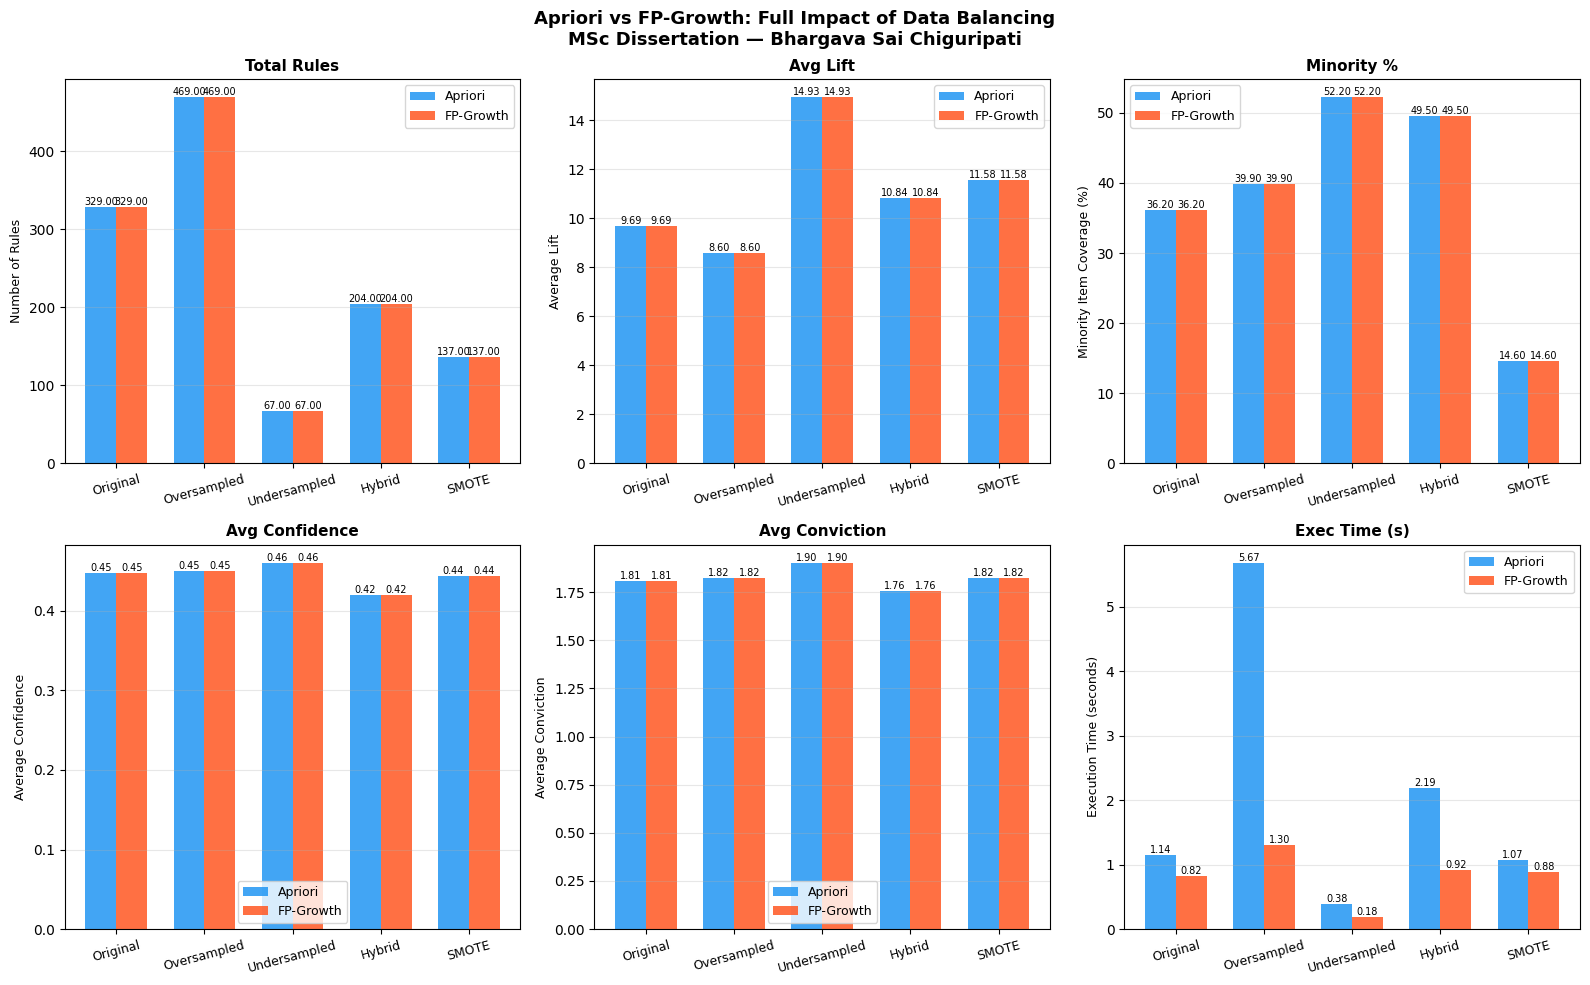

Saved: outputs/fig3_full_comparison.png


In [34]:
dataset_order = ['Original', 'Oversampled', 'Undersampled', 'Hybrid', 'SMOTE']
x = np.arange(len(dataset_order))
w = 0.35
ap_color = '#2196F3'
fp_color = "#FF5722"

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

metrics = [
    ('Total Rules',   'Number of Rules'),
    ('Avg Lift',      'Average Lift'),
    ('Minority %',    'Minority Item Coverage (%)'),
    ('Avg Confidence','Average Confidence'),
    ('Avg Conviction','Average Conviction'),
    ('Exec Time (s)', 'Execution Time (seconds)'),
]

for ax, (metric, ylabel) in zip(axes, metrics):
    ap_vals = [summary[(summary['Dataset']==d) &
                       (summary['Algorithm']=='Apriori')][metric].values[0]
               for d in dataset_order]
    fp_vals = [summary[(summary['Dataset']==d) &
                       (summary['Algorithm']=='FP-Growth')][metric].values[0]
               for d in dataset_order]

    b1 = ax.bar(x - w/2, ap_vals, w, label='Apriori',   color=ap_color, alpha=0.85)
    b2 = ax.bar(x + w/2, fp_vals, w, label='FP-Growth', color=fp_color, alpha=0.85)

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)

    ax.set_title(metric, fontweight='bold', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_order, rotation=15, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Apriori vs FP-Growth: Full Impact of Data Balancing\n'
             'MSc Dissertation — Bhargava Sai Chiguripati',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig3_full_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig3_full_comparison.png')

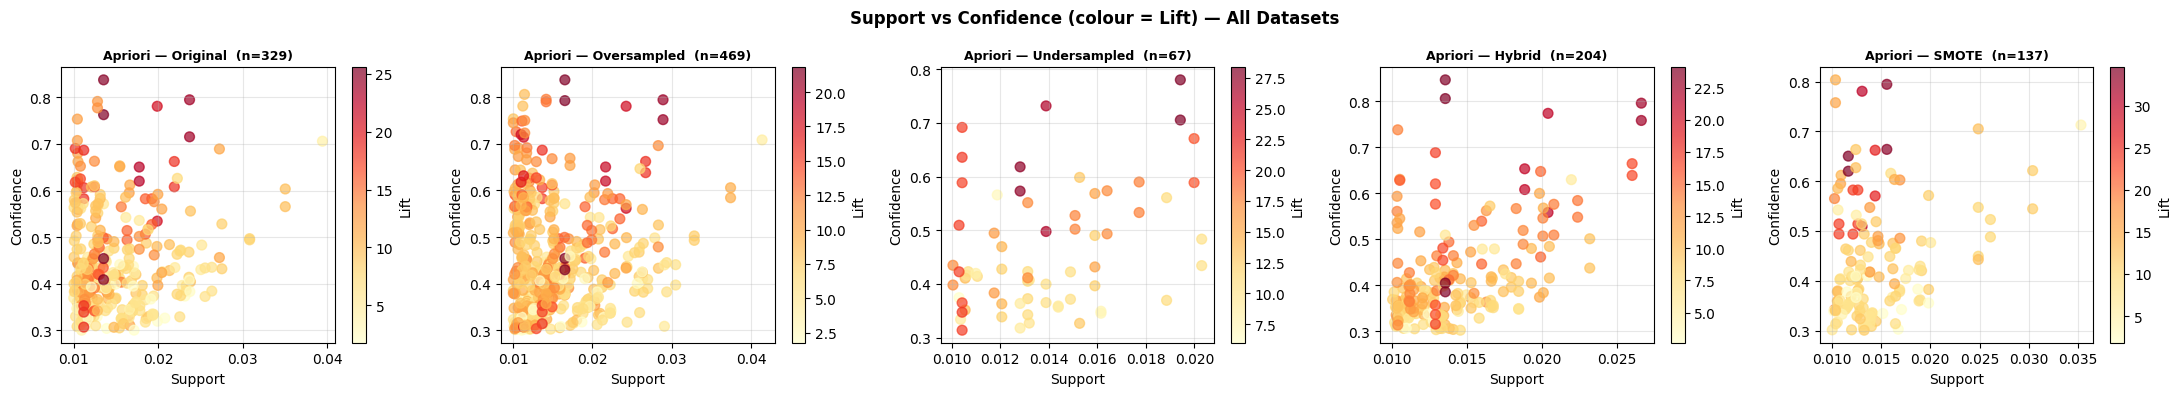

Saved: outputs/fig4_scatter.png


In [35]:
#  Support vs Confidence scatter plot for all datasets
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, ds in zip(axes, dataset_order):
    rules = all_results[ds]['Apriori']['rules']
    if len(rules) == 0:
        ax.text(0.5, 0.5, 'No rules', ha='center', transform=ax.transAxes)
    else:
        sc = ax.scatter(rules['support'], rules['confidence'],
                        c=rules['lift'], cmap='YlOrRd', s=50, alpha=0.7)
        plt.colorbar(sc, ax=ax, label='Lift')
    ax.set_title(f'Apriori — {ds}  (n={len(rules)})', fontweight='bold', fontsize=9)
    ax.set_xlabel('Support')
    ax.set_ylabel('Confidence')
    ax.grid(alpha=0.3)

plt.suptitle('Support vs Confidence (colour = Lift) — All Datasets', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig4_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig4_scatter.png')

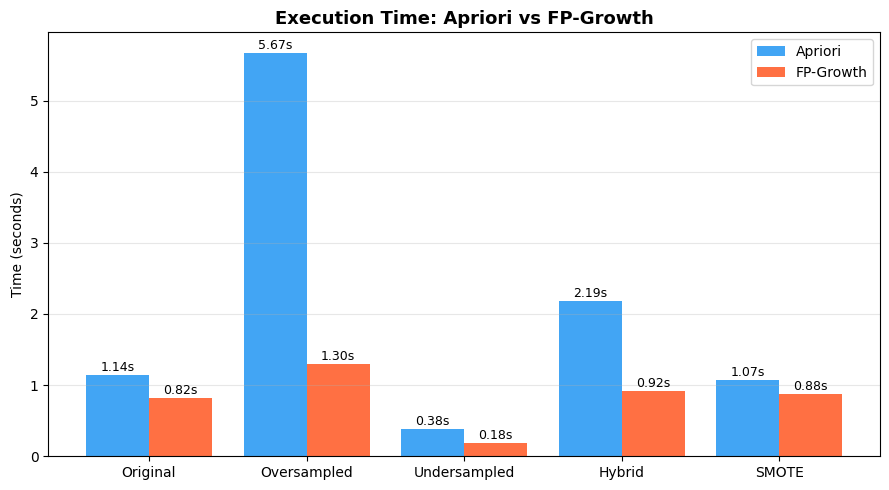

Saved: outputs/fig5_execution_time.png


In [36]:
fig, ax = plt.subplots(figsize=(9, 5))

ap_times = [summary[(summary['Dataset']==d) &
                    (summary['Algorithm']=='Apriori')]['Exec Time (s)'].values[0]
            for d in dataset_order]
fp_times = [summary[(summary['Dataset']==d) &
                    (summary['Algorithm']=='FP-Growth')]['Exec Time (s)'].values[0]
            for d in dataset_order]

x = np.arange(len(dataset_order))
b1 = ax.bar(x - 0.2, ap_times, 0.4, label='Apriori',   color='#2196F3', alpha=0.85)
b2 = ax.bar(x + 0.2, fp_times, 0.4, label='FP-Growth', color='#FF5722', alpha=0.85)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f'{h:.2f}s', ha='center', va='bottom', fontsize=9)

ax.set_title('Execution Time: Apriori vs FP-Growth', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(dataset_order)
ax.set_ylabel('Time (seconds)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/fig5_execution_time.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig5_execution_time.png')

In [37]:
print('TOP 10 Rules by Lift')

for dataset_name in dataset_order:
    for algo in ['Apriori', 'FP-Growth']:
        rules = all_results[dataset_name][algo]['rules']
        if len(rules) == 0:
            print(f'[{dataset_name} | {algo}] — No rules found')
            continue
        top = rules.sort_values('lift', ascending=False).head(10).copy()
        top['antecedents'] = top['antecedents'].apply(lambda x: ', '.join(list(x)))
        top['consequents'] = top['consequents'].apply(lambda x: ', '.join(list(x)))
        print(f'[{dataset_name} | {algo}]')
        print(top[['antecedents','consequents','support',
                   'confidence','lift','conviction']].to_string(index=False))

TOP 10 Rules by Lift
[Original | Apriori]
                                              antecedents                                               consequents  support  confidence      lift  conviction
ROSES REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER                           GREEN REGENCY TEACUP AND SAUCER 0.013555    0.762677 25.549696    4.087894
                          GREEN REGENCY TEACUP AND SAUCER ROSES REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER 0.013555    0.454106 25.549696    1.799300
GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER                           ROSES REGENCY TEACUP AND SAUCER 0.013555    0.837416 25.248107    5.946682
                          ROSES REGENCY TEACUP AND SAUCER GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKESTAND 3 TIER 0.013555    0.408696 25.248107    1.663801
                          ROSES REGENCY TEACUP AND SAUCER                           GREEN REGENCY TEACUP AND SAUCER 0.023722    0.715217 23.959783    3.406631
    

In [38]:
# Save all rule CSVs
for dataset_name, algo_results in all_results.items():
    for algo_name, s in algo_results.items():
        rules = s['rules'].copy()
        if len(rules) == 0:
            continue
        rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
        fname = (f"outputs/rules_{dataset_name.lower()}_"
                 f"{algo_name.lower().replace('-','')}.csv")
        rules.sort_values('lift', ascending=False).to_csv(fname, index=False)
        print('Saved')

# Save summary as Excel
summary.to_excel('outputs/results_summary.xlsx', index=False)
print('Saved: outputs/results_summary.xlsx')

print('OUTPUT FILES')
for f in sorted(os.listdir('outputs')):
    size = os.path.getsize(f'outputs/{f}')
    print(f'  outputs/{f}  ({size:,} bytes)')

Saved
Saved
Saved
Saved
Saved
Saved
Saved
Saved
Saved
Saved
Saved: outputs/results_summary.xlsx
OUTPUT FILES
  outputs/fig1_imbalance.png  (350,221 bytes)
  outputs/fig2_balance_comparison.png  (199,337 bytes)
  outputs/fig3_full_comparison.png  (433,859 bytes)
  outputs/fig4_scatter.png  (1,068,216 bytes)
  outputs/fig5_execution_time.png  (98,451 bytes)
  outputs/fig6_gini_comparison.png  (98,675 bytes)
  outputs/fig7_wordcloud.png  (1,701,586 bytes)
  outputs/fig8_minority_coverage.png  (114,715 bytes)
  outputs/results_summary.xlsx  (5,683 bytes)
  outputs/results_table.csv  (871 bytes)
  outputs/rules_hybrid_apriori.csv  (57,149 bytes)
  outputs/rules_hybrid_fpgrowth.csv  (57,149 bytes)
  outputs/rules_original_apriori.csv  (92,711 bytes)
  outputs/rules_original_fpgrowth.csv  (92,711 bytes)
  outputs/rules_oversampled_apriori.csv  (133,324 bytes)
  outputs/rules_oversampled_fpgrowth.csv  (133,324 bytes)
  outputs/rules_smote_apriori.csv  (38,239 bytes)
  outputs/rules_smote_fpgro

In [39]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wordcloud', '-q'])
print('Installed')

Installed


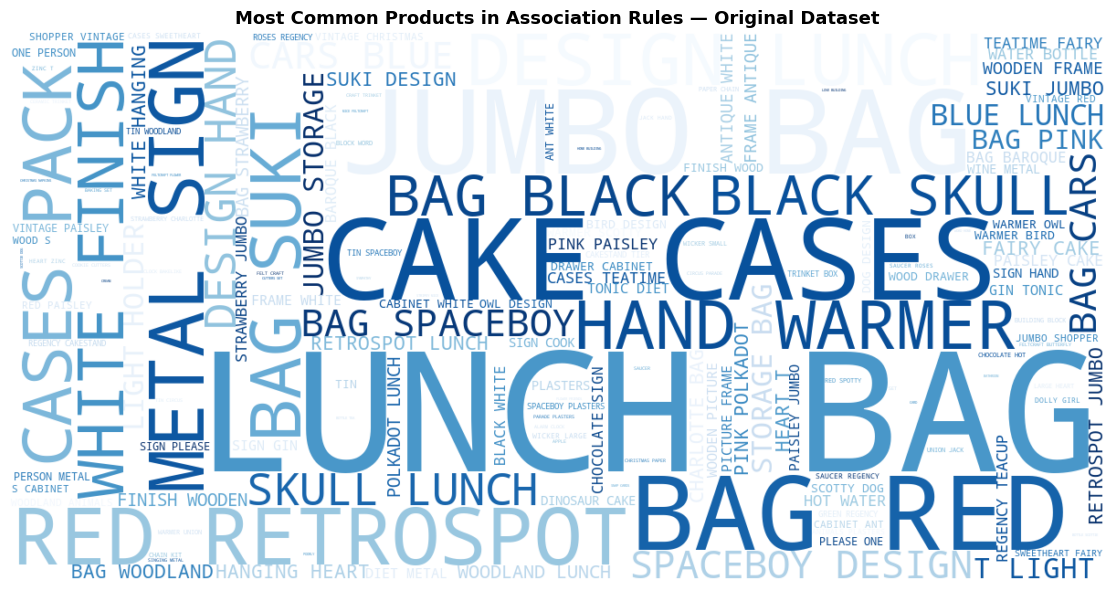

Saved: outputs/fig7_wordcloud.png


In [40]:
from wordcloud import WordCloud

all_items = []
for _, row in rules_ap_orig.iterrows():
    all_items.extend(list(row['antecedents']) + list(row['consequents']))

wc = WordCloud(width=1200, height=600,
               background_color='white',
               colormap='Blues')
wc.generate(' '.join(all_items))

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Products in Association Rules — Original Dataset',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/fig7_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig7_wordcloud.png')

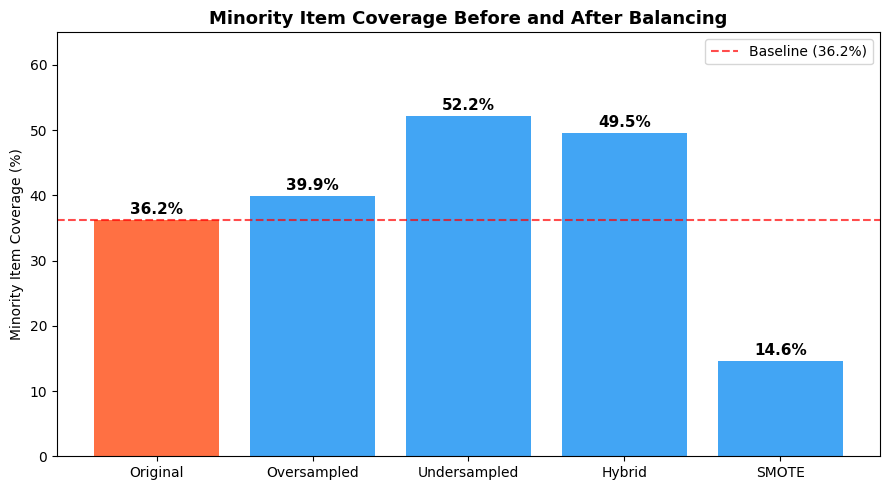

Saved: outputs/fig8_minority_coverage.png


In [41]:
methods = ['Original', 'Oversampled', 'Undersampled', 'Hybrid', 'SMOTE']
minority_pct = [36.2, 39.9, 52.2, 49.5, 14.6]
colors = ['#FF5722' if x == 36.2 else '#2196F3' for x in minority_pct]

plt.figure(figsize=(9, 5))
bars = plt.bar(methods, minority_pct, color=colors, alpha=0.85)

for bar, val in zip(bars, minority_pct):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.axhline(y=36.2, color='red', linestyle='--', alpha=0.7, label='Baseline (36.2%)')
plt.title('Minority Item Coverage Before and After Balancing',
          fontweight='bold', fontsize=13)
plt.ylabel('Minority Item Coverage (%)')
plt.ylim(0, 65)
plt.legend()
plt.tight_layout()
plt.savefig('outputs/fig8_minority_coverage.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: outputs/fig8_minority_coverage.png')